### 1: Import all Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 2: Import the Dataset

In [2]:
df=pd.read_csv('../input/titanic/train.csv')

### 3: Data overview


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#numbers of output
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### 4: Preprocessing :


#### dealing with outliers:

In [7]:
df.corr()['Survived'].sort_values()

Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
PassengerId   -0.005007
Parch          0.081629
Fare           0.257307
Survived       1.000000
Name: Survived, dtype: float64

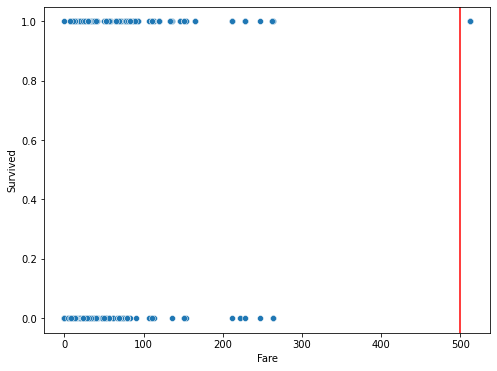

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Fare', y='Survived')
plt.axvline(x=500,color='r')

In [9]:
df[df['Fare']>500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


According to the previous scatter plot, we  do not have  more than 500 for normal and that's are drop data so I  replace this amount with mean of 1st level's Fare.

In [10]:
df.iloc[[258,679,737],6]=df[df['Pclass']==1]['Fare'].mean()


In [11]:
df[df['Fare']>500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,84.154687,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,84.154687,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,84.154687,0,PC 17755,512.3292,B101,C


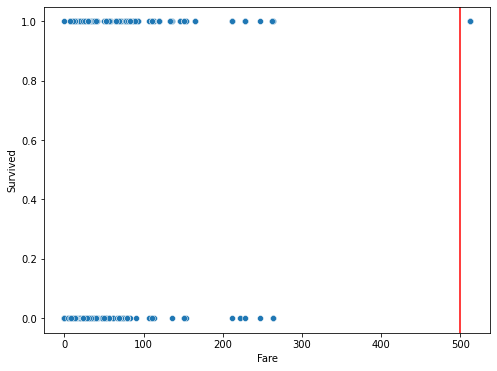

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Fare', y='Survived')
plt.axvline(x=500,color='r')

In [13]:
df.corr()['Survived'].sort_values()


Pclass        -0.338481
Age           -0.077221
PassengerId   -0.005007
SibSp          0.064424
Parch          0.081629
Fare           0.257307
Survived       1.000000
Name: Survived, dtype: float64

#### dealing with missing data:

In [14]:
df.isnull().sum().sort_values()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Age            177
Cabin          687
dtype: int64

#### Make a Function to calculate the percent of missing data in each columns (feature) and then sort it

In [15]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [16]:
nan_percent= missing_percent(df)
nan_percent

Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64

<AxesSubplot:>

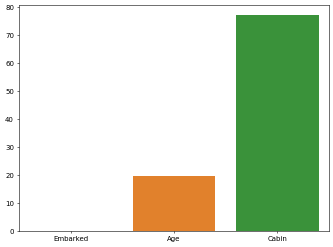

In [17]:
plt.figure(figsize=(8,6),dpi=50)
sns.barplot(x=nan_percent.index,y=nan_percent)

In [18]:
100/len(df)

0.1122334455667789

Embarked has 2 rows of missing data.



In [19]:
df[df['Embarked'].isnull()]['Embarked']


61     NaN
829    NaN
Name: Embarked, dtype: object

In [20]:
df.iloc[[61,829]]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0.0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0.0,0,113572,80.0,B28,NaN


In [21]:
df=df.dropna(axis=0, subset=['Embarked'])


<AxesSubplot:>

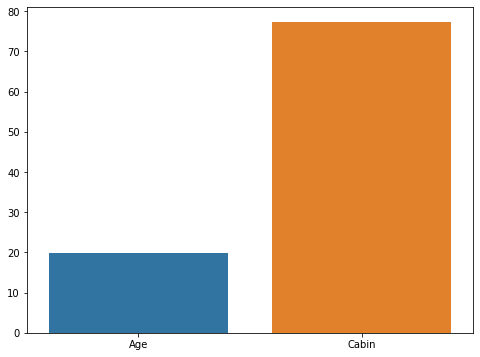

In [22]:
nan_percent= missing_percent(df)
plt.figure(figsize=(8,6))
sns.barplot(x=nan_percent.index,y=nan_percent)

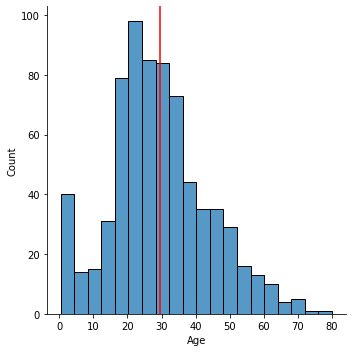

In [23]:
sns.displot(df['Age'])
plt.axvline(x=(df['Age'].mean()),color='r')

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

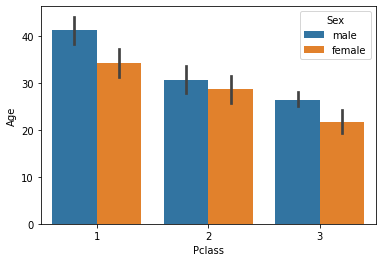

In [24]:
sns.barplot(data=df,x='Pclass',y='Age',hue='Sex')

####calculating mean of age according to sex and ticket class:


In [25]:
df.groupby(['Sex', 'Pclass'])['Age'].mean()


Sex     Pclass
female  1         34.240964
        2         28.722973
        3         21.750000
male    1         41.281386
        2         30.740707
        3         26.507589
Name: Age, dtype: float64

In [26]:
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].apply(lambda x: x.fillna(x.mean()))


In [27]:
nan_percent= missing_percent(df)
nan_percent

Cabin    77.27784
dtype: float64

#### dealing with categorical features:

In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    float64
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.6+ KB


In [29]:
df['Survived'].unique()

array([0, 1])

In [30]:
df['Pclass'].unique()

array([3, 1, 2])

#### Convert to String:


In [31]:
df['Survived']= df['Survived'].apply(str)
df['Pclass']= df['Pclass'].apply(str)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    object 
 2   Pclass       889 non-null    object 
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    float64
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 122.6+ KB


####  Creating Dummy Variables:

In [33]:
df.select_dtypes(include='object')

,Survived,Pclass,Name,Sex,Ticket,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,0,3,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,211536,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,111369,C148,C


In [34]:
df_num= df.select_dtypes(exclude='object')
df_obj= df.select_dtypes(include='object')

In [35]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Age          889 non-null    float64
 2   SibSp        889 non-null    float64
 3   Parch        889 non-null    int64  
 4   Fare         889 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 74.0 KB


In [36]:
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  889 non-null    object
 1   Pclass    889 non-null    object
 2   Name      889 non-null    object
 3   Sex       889 non-null    object
 4   Ticket    889 non-null    object
 5   Cabin     202 non-null    object
 6   Embarked  889 non-null    object
dtypes: object(7)
memory usage: 87.9+ KB


#### Converting:

In [37]:
df_obj= pd.get_dummies(df_obj, drop_first=True)

In [38]:
df_obj.shape

(889, 1718)

In [39]:
final_df= pd.concat([df_num, df_obj], axis=1)
final_df.head()

,PassengerId,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,22.0,1.0,0,7.2500,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,38.0,1.0,0,71.2833,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,26.0,0.0,0,7.9250,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,35.0,1.0,0,53.1000,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,35.0,0.0,0,8.0500,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


#### Now, the Dataset is Ready for any Machine Learing Model & Analysis



### 5: Exploratory Data Analysis

<AxesSubplot:xlabel='Age', ylabel='Fare'>

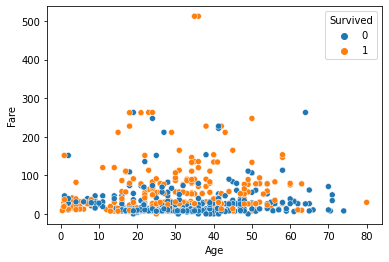

In [40]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')

<AxesSubplot:xlabel='Survived', ylabel='count'>

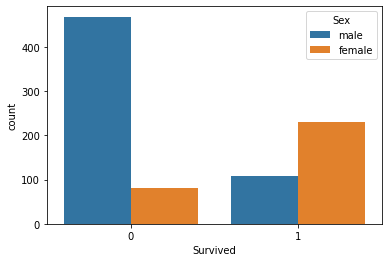

In [41]:
sns.countplot(data=df, x='Survived',hue='Sex')

#### This Plot  shows that females are more survived than males.

<AxesSubplot:xlabel='Survived', ylabel='Age'>

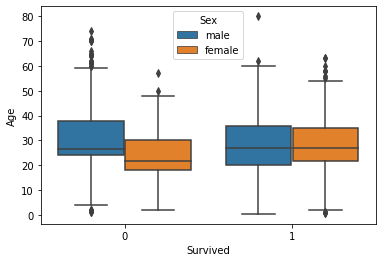

In [42]:
sns.boxplot(data=df,x='Survived',y='Age',hue='Sex')

#### Most of those who died were between the ages of 20 and 50

#### Removing unnecessary features


In [43]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

<AxesSubplot:>

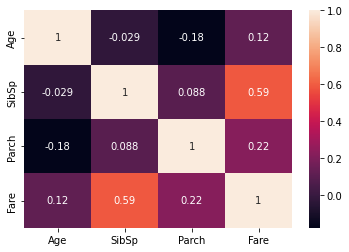

In [44]:
sns.heatmap(data=df.corr(),annot=True)

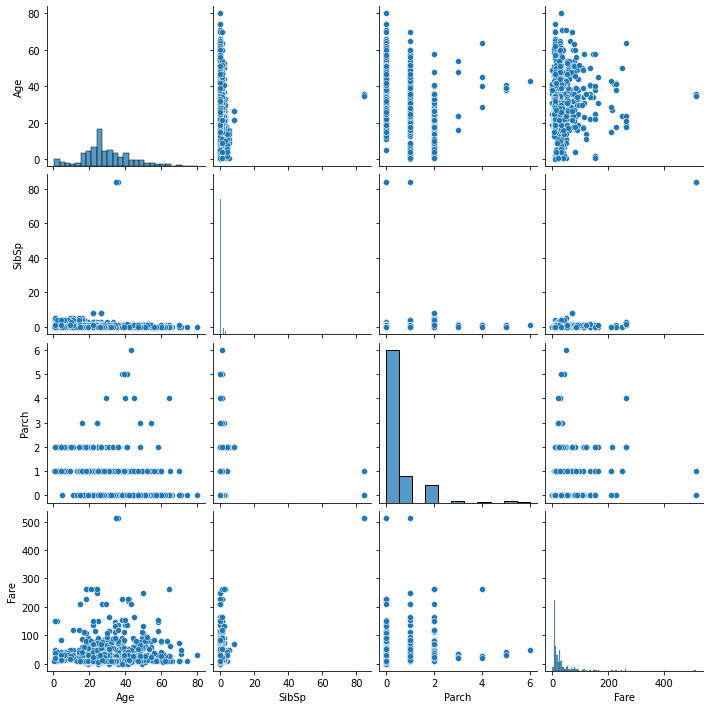

In [45]:
sns.pairplot(df)

<AxesSubplot:xlabel='Survived', ylabel='count'>

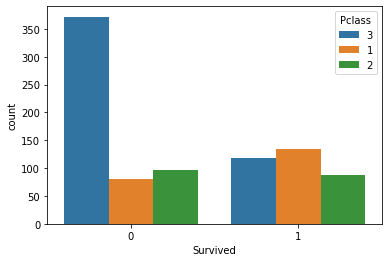

In [46]:
sns.countplot(data=df,x='Survived',hue='Pclass')

#### The most dead people are from 3th ticket class which is the cheapest ticket.

<AxesSubplot:xlabel='SibSp', ylabel='count'>

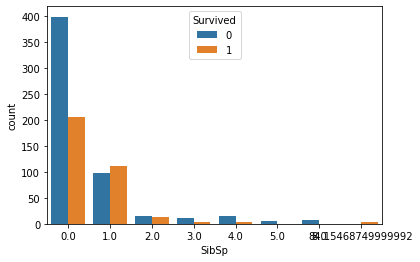

In [47]:
sns.countplot(data=df, x='SibSp',hue='Survived')

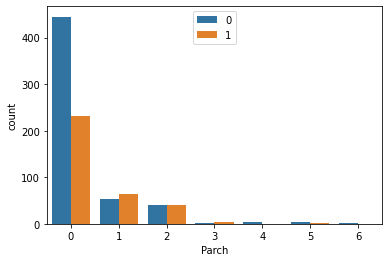

In [48]:
sns.countplot(data=df, x='Parch',hue='Survived')
plt.legend(loc= 9)

### 6: Logistic Regression


<AxesSubplot:xlabel='Survived_1', ylabel='count'>

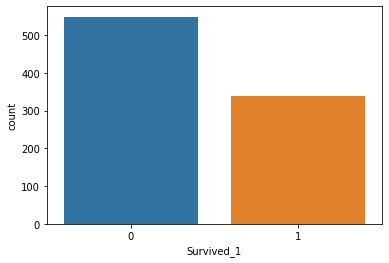

In [49]:
sns.countplot(data=final_df,x='Survived_1')


 Data is balanced.



#### Determine the Features & Target Variable


In [50]:
X=final_df.drop('Survived_1',axis=1)
y=final_df['Survived_1']


#### Split the Dataset to Tain & Test set:


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=102)


#### Scaling the Features


In [52]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X_train)
scaled_X_train= scaler.transform(X_train)
scaled_X_test= scaler.transform(X_test)

#### Train the Model


In [53]:
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression()
log_model.fit(scaled_X_train, y_train)

LogisticRegression()

#### Model Coeficient:

In [54]:
log_model.coef_


array([[-0.01740328, -0.22259688,  0.04531498, ..., -0.04678703,
        -0.00219438, -0.22721151]])

#### Predicting Test Data

In [55]:
y_pred= log_model.predict(scaled_X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0], dtype=uint8)

#### Evaluating the Model

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix
accuracy_score(y_test, y_pred)

0.7752808988764045

In [57]:
confusion_matrix(y_test, y_pred)

array([[58,  3],
       [17, 11]])

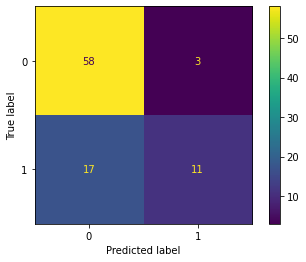

In [58]:
plot_confusion_matrix(log_model, scaled_X_test, y_test)

In [59]:
accuracy_score(y_test, y_pred)

0.7752808988764045

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.95      0.85        61
           1       0.79      0.39      0.52        28

    accuracy                           0.78        89
   macro avg       0.78      0.67      0.69        89
weighted avg       0.78      0.78      0.75        89



#### Evaluating Curves and AUC

In [61]:
from sklearn.metrics import precision_recall_curve, plot_precision_recall_curve, plot_roc_curve

#### visualizing ROC plot <br>
#### Plotting ROC for random guessing

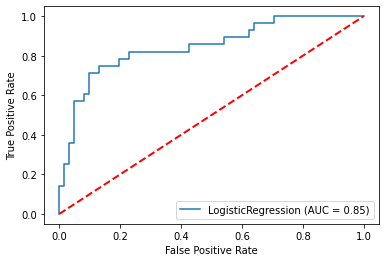

In [62]:
plot_roc_curve(log_model, scaled_X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r')
plt.show()

#### visualizing precision-Recall plot

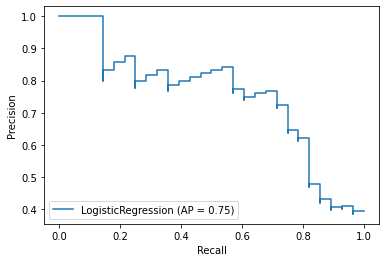

In [63]:
plot_precision_recall_curve(log_model, scaled_X_test, y_test)

### K-Nearest Neighbors


#### train the model

In [64]:
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=1)


In [65]:
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [66]:
y_pred= knn_model.predict(scaled_X_test)

In [67]:
accuracy_score(y_test, y_pred)

0.7303370786516854

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_score(y_test, y_pred)


0.7303370786516854

The accuracy using KNN algorithm with one neighbor is : 0.73


#### Predicting Test Data:

In [69]:
y_pred=knn_model.predict(scaled_X_test)
pd.DataFrame({'y_test':y_test,'y_pred':y_pred})

,y_test,y_pred
378,0,0
143,0,0
614,0,0
363,0,0
676,0,0
...,...,...
316,1,0
353,0,0
439,0,0
505,0,1


In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.93      0.83        61
           1       0.67      0.29      0.40        28

    accuracy                           0.73        89
   macro avg       0.70      0.61      0.61        89
weighted avg       0.72      0.73      0.69        89



### Elbow Method for Choosing Reasonable K Values


In [71]:
test_error_rate= []


for k in range (1, 30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train, y_train)
    
    y_pred_test = knn_model.predict(scaled_X_test)
    
    test_error=1- accuracy_score(y_test, y_pred_test)
    test_error_rate.append(test_error)

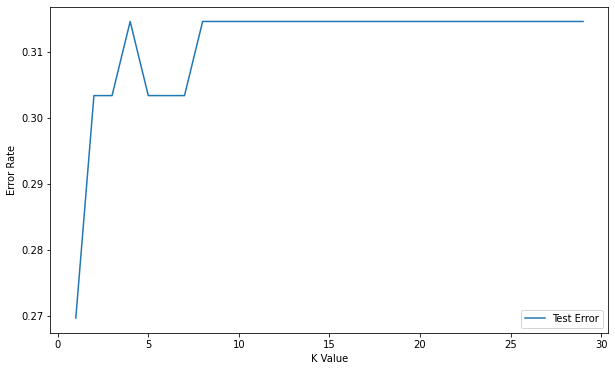

In [72]:
plt.figure(figsize=(10 , 6))
plt.plot(range(1, 30), test_error_rate, label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel('K Value')
plt.show()

so I choose K=10 cause it has a significantly lower Error rate

Train the model with 10 neighbors

In [73]:
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=2)

In [74]:
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [75]:
y_pred= knn_model.predict(scaled_X_test)


In [76]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_score(y_test, y_pred)

0.6966292134831461